# EDA

first look at the three datasets before I build anything. mostly just checking class balance,
clip lengths, what the attacks look like, and whether there's an obvious shortcut (silence etc)
that a model could cheat with.

reads the csvs from `scripts/verify_data.py --full`, doesn't touch the raw audio much.

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
import librosa.display
import yaml
from sklearn.metrics import roc_curve

pd.set_option("display.max_columns", None)

In [5]:
REPO = "/mnt/d/DeepLearning/voice-deepfake-detection"

In [6]:
with open(f"{REPO}/configs/paths.yaml") as f:
    paths = yaml.safe_load(f)

data_root = paths["data_root"]
report_dir = f"{paths['outputs_root']}/data_report"

In [7]:
audio_dirs = {
    "la19_train": paths["asvspoof2019_la"]["train_flac"],
    "la19_dev": paths["asvspoof2019_la"]["dev_flac"],
    "la19_eval": paths["asvspoof2019_la"]["eval_flac"],
    "asv5_dev": paths["asvspoof5"]["dev_flac"],
    "asv5_eval": paths["asvspoof5"]["eval_flac"],
    "itw": paths["itw"]["audio"],
}
splits = list(audio_dirs)

SR = 16000
CROP = 64600 / SR  # ~4s, the fixed model input length
colors = {"bonafide": "tab:blue", "spoof": "tab:red"}

In [8]:
summary = pd.read_csv(f"{report_dir}/summary.csv")

In [9]:
summary

,split,protocol_rows,files_on_disk,usable,missing,extra,bonafide,spoof,headers_checked,unreadable
0,la19_train,25380,25380,25380,0,0,2580,22800,25380,0
1,la19_dev,24844,24986,24844,0,142,2548,22296,24844,0
2,la19_eval,71237,71933,71237,0,696,7355,63882,71237,0
3,asv5_dev,140950,142134,140950,0,1184,31334,109616,140950,0
4,asv5_eval,680774,136376,136376,544398,0,28064,108312,136376,0
5,itw,31779,31779,31779,0,0,19963,11816,31779,0


In [10]:
audio = {s: pd.read_csv(f"{report_dir}/{s}_audio.csv", keep_default_na=False) for s in splits}
{s: len(df) for s, df in audio.items()}

{'la19_train': 25380,
 'la19_dev': 24844,
 'la19_eval': 71237,
 'asv5_dev': 140950,
 'asv5_eval': 136376,
 'itw': 31779}

## class balance

In [11]:
summary["pct_bonafide"] = 100 * summary.bonafide / (summary.bonafide + summary.spoof)

In [12]:
summary[["split", "bonafide", "spoof", "pct_bonafide"]].round(1)

,split,bonafide,spoof,pct_bonafide
0,la19_train,2580,22800,10.2
1,la19_dev,2548,22296,10.3
2,la19_eval,7355,63882,10.3
3,asv5_dev,31334,109616,22.2
4,asv5_eval,28064,108312,20.6
5,itw,19963,11816,62.8


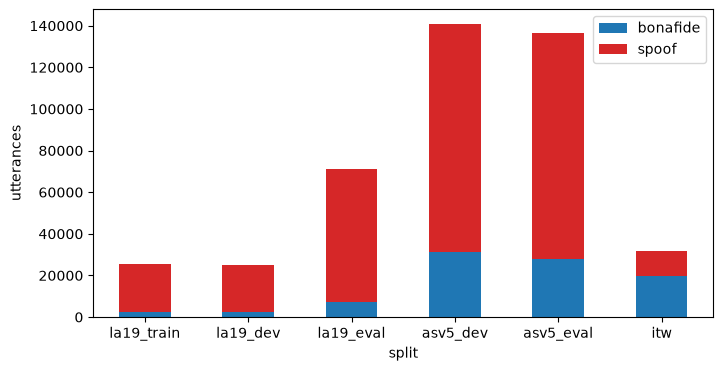

In [13]:
summary.set_index("split")[["bonafide", "spoof"]].plot.bar(
    stacked=True, color=colors.values(), figsize=(8, 4), rot=0, ylabel="utterances")
plt.show()

2019 LA is like 90% spoof, ASVspoof5 less skewed, ITW is mostly bonafide - opposite direction. def need weighted loss / balanced sampling for training.

## durations

dashed line is the 4s crop. anything shorter than that gets repeat-padded.

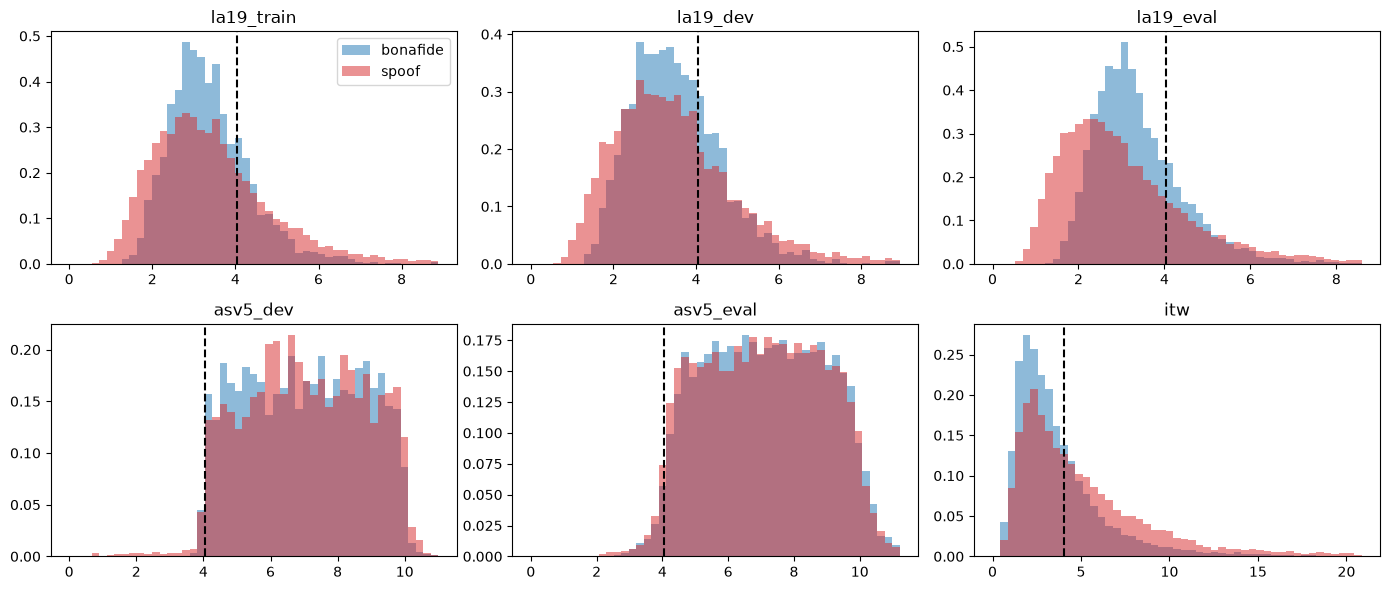

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, s in zip(axes.flat, splits):
    df = audio[s]
    bins = np.linspace(0, df.duration_s.quantile(0.995), 50)
    for label in ["bonafide", "spoof"]:
        ax.hist(df[df.label == label].duration_s, bins=bins, density=True, alpha=0.5, color=colors[label], label=label)
    ax.axvline(CROP, color="k", ls="--")
    ax.set_title(s)
axes[0, 0].legend()
plt.tight_layout()
plt.show()

In [15]:
for s in splits:
    df = audio[s]
    pct_short = 100 * (df.duration_s < CROP).mean()
    print(f"{s:12s} median {df.duration_s.median():.2f}s   % under 4s: {pct_short:.0f}%")

la19_train   median 3.20s   % under 4s: 73%
la19_dev     median 3.28s   % under 4s: 71%
la19_eval    median 2.82s   % under 4s: 78%
asv5_dev     median 7.04s   % under 4s: 2%
asv5_eval    median 7.10s   % under 4s: 3%
itw          median 3.27s   % under 4s: 62%


most of 2019 + ITW is under 4s so gets padded a lot. ASVspoof5 clips around 7s so barely any padding, also means we are only scoring half the clip at eval time. 
ITW spoof clips seem to run longer than bonafide ones on average

In [ ]:
audio["itw"].groupby("label").duration_s.median()

label
bonafide    2.991000
spoof       4.045531
Name: duration_s, dtype: float64

## attacks / codecs

In [17]:
spoof_train = audio["la19_train"][audio["la19_train"].label == "spoof"]
spoof_eval = audio["la19_eval"][audio["la19_eval"].label == "spoof"]

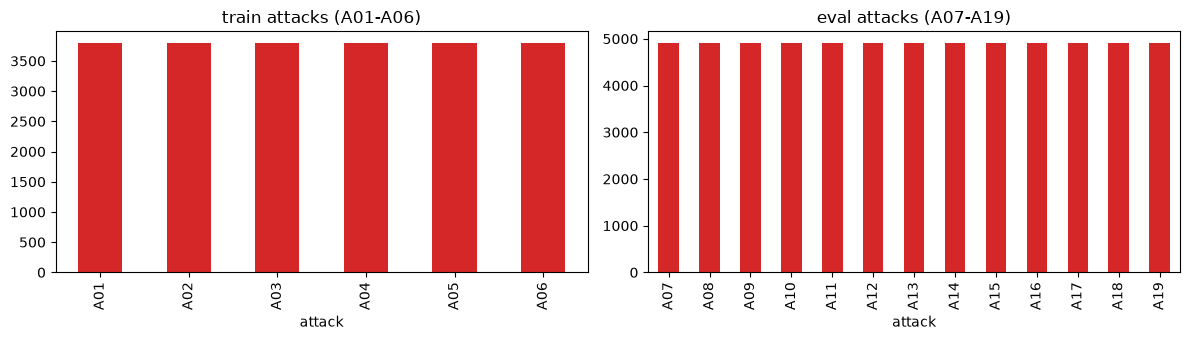

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
spoof_train.attack.value_counts().sort_index().plot.bar(ax=axes[0], color="tab:red", title="train attacks (A01-A06)")
spoof_eval.attack.value_counts().sort_index().plot.bar(ax=axes[1], color="tab:red", title="eval attacks (A07-A19)")
plt.tight_layout()
plt.show()

no overlap between train and eval attack IDs, so 2019 eval is a proper unseen-attack test.

In [21]:
for s in ["asv5_dev", "asv5_eval"]:
    print(s)
    print(audio[s].codec.value_counts())
    print()

asv5_dev
codec
-    140950
Name: count, dtype: int64

asv5_eval
codec
-      33763
C07     9651
C03     9617
C10     9617
C01     9590
C05     9578
C04     9530
C08     9525
C11     9445
C02     9440
C09     8368
C06     8252
Name: count, dtype: int64



what audio actually looks like

In [22]:
def load(split, fname):
    y, sr = sf.read(f"{data_root}/{audio_dirs[split]}/{fname}", dtype="float32")
    assert sr == SR
    return y

In [23]:
def melspec(y):
    S = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=512, win_length=400, hop_length=160, n_mels=80)
    return librosa.power_to_db(S, ref=np.max)

In [24]:
def peek(split, rows):
    fig, axes = plt.subplots(2, len(rows), figsize=(3.5 * len(rows), 5))
    for j, (_, r) in enumerate(rows.iterrows()):
        y = load(split, r.filename)
        axes[0, j].plot(np.arange(len(y)) / SR, y, lw=0.3, color=colors[r.label])
        axes[0, j].set_title(f"{r.label} {r.attack}", fontsize=9)
        librosa.display.specshow(melspec(y), sr=SR, hop_length=160, x_axis="time", y_axis="mel", ax=axes[1, j])
    plt.tight_layout()
    plt.show()

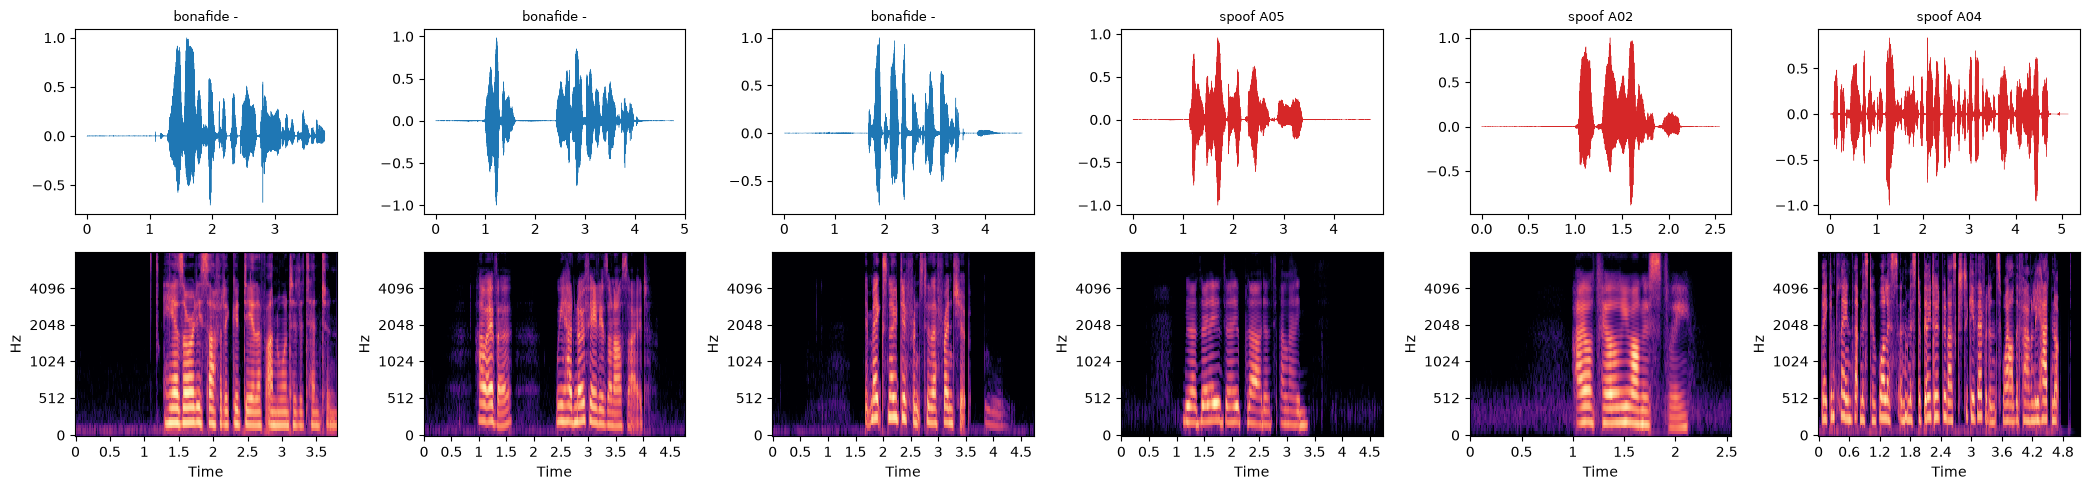

In [25]:
df = audio["la19_train"]
rows = pd.concat([df[df.label == "bonafide"].sample(3, random_state=0),
                  df[df.label == "spoof"].sample(3, random_state=0)])
peek("la19_train", rows)

bonafide vs each training attack. keeps the voice constant so it's easier to spot what's different

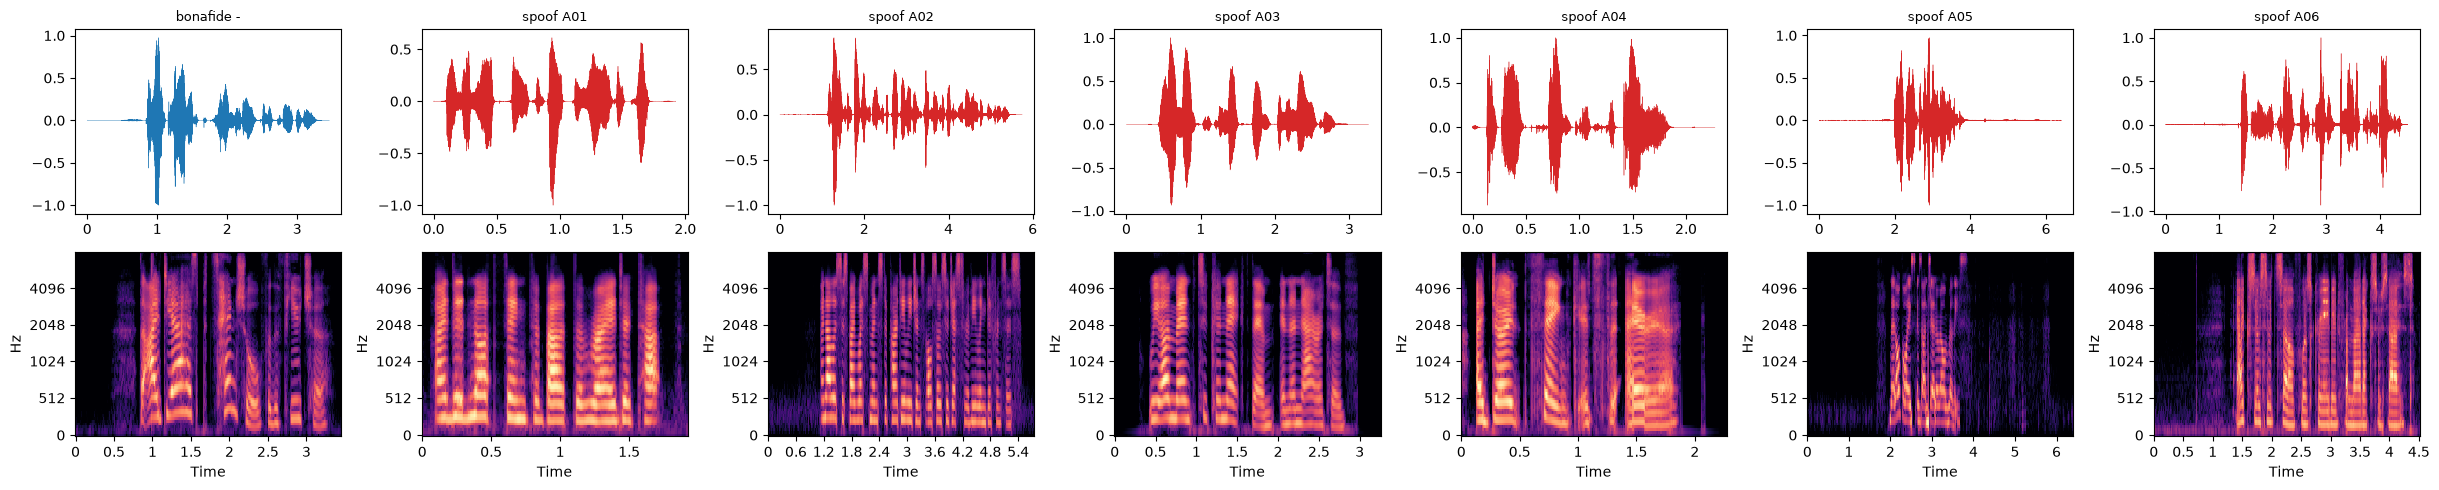

In [26]:
spk = df.speaker.iloc[0]
same_speaker = df[df.speaker == spk]
rows = [same_speaker[same_speaker.label == "bonafide"].iloc[:1]]
for a in ["A01", "A02", "A03", "A04", "A05", "A06"]:
    rows.append(same_speaker[same_speaker.attack == a].iloc[:1])
peek("la19_train", pd.concat(rows))

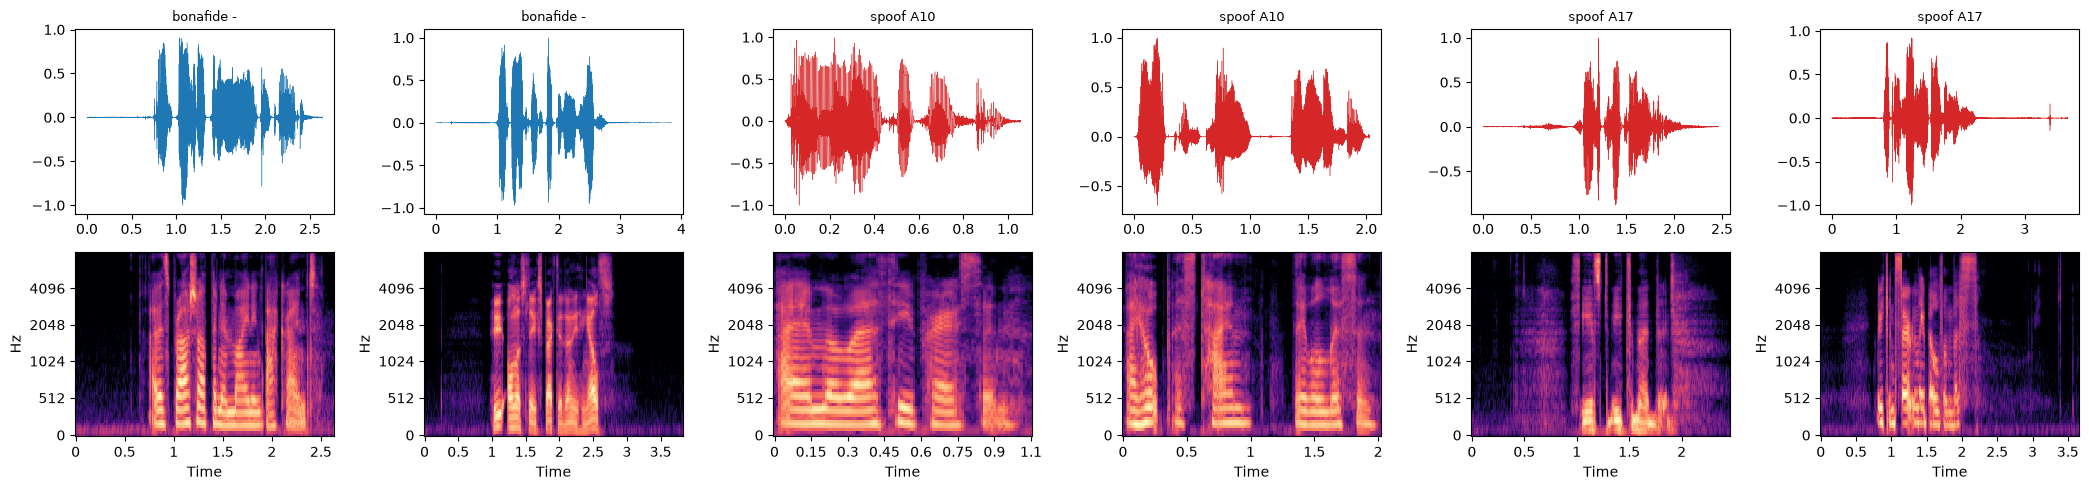

In [27]:
ev = audio["la19_eval"]
rows = pd.concat([ev[ev.label == "bonafide"].sample(2, random_state=1),
                  ev[ev.attack == "A10"].sample(2, random_state=1),
                  ev[ev.attack == "A17"].sample(2, random_state=1)])
peek("la19_eval", rows)

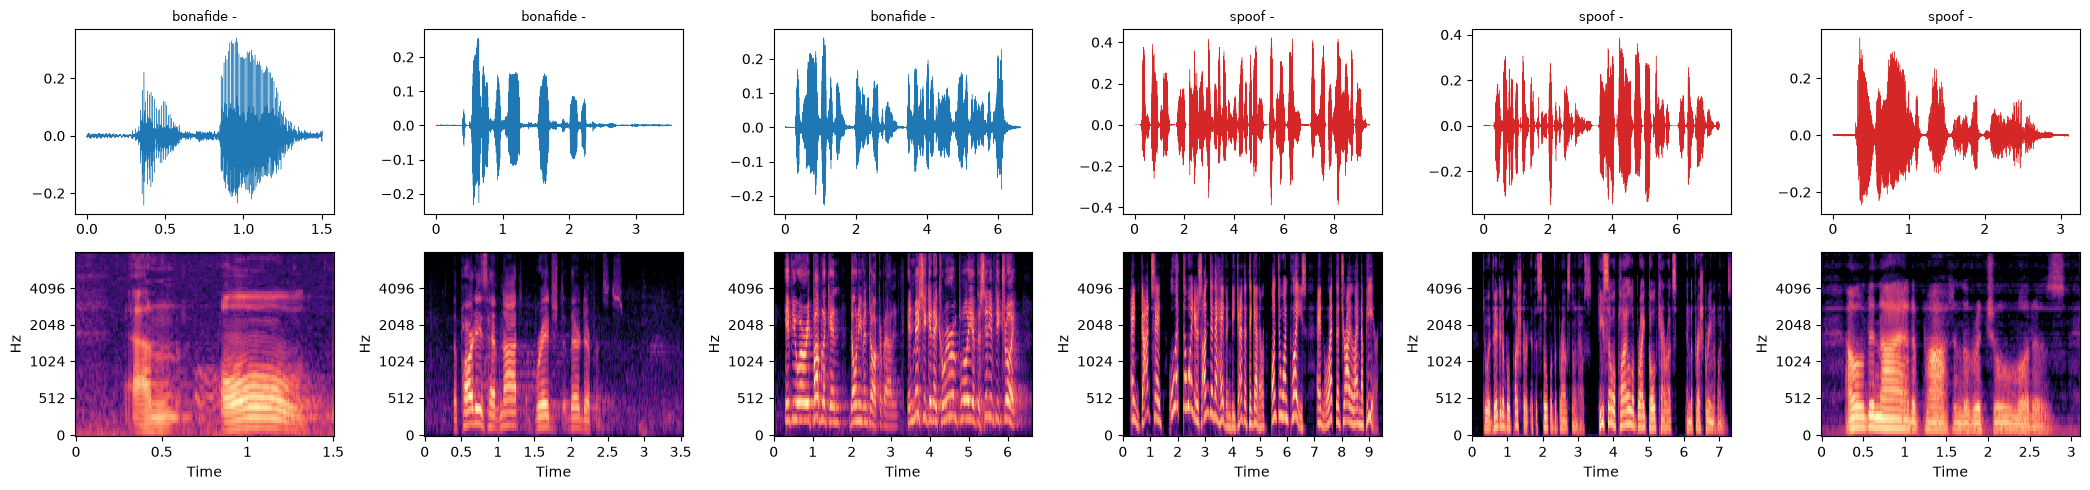

In [28]:
itw = audio["itw"]
rows = pd.concat([itw[itw.label == "bonafide"].sample(3, random_state=0),
                  itw[itw.label == "spoof"].sample(3, random_state=0)])
peek("itw", rows)

ITW is lower quality than 2019 (scraped from the internet rather than studio recordings)

## silence shortcut

known issue with ASVspoof 2019. 

bonafide clips tend to have more trailing silence than spoofed ones, so model can learn more silence = real without listening to the actual speech

In [29]:
def edge_silence(y, top_db=40):
    _, (start, end) = librosa.effects.trim(y, top_db=top_db, frame_length=512, hop_length=128)
    return start / SR, (len(y) - end) / SR

In [30]:
def sample_silence(split, n=500, seed=0):
    df = audio[split]
    rows = pd.concat([g.sample(min(n, len(g)), random_state=seed) for _, g in df.groupby("label")])
    lead, trail = zip(*[edge_silence(load(split, f)) for f in rows.filename])
    return rows.assign(lead_s=lead, trail_s=trail)

In [31]:
sil_train = sample_silence("la19_train")
sil_asv5 = sample_silence("asv5_dev")
sil_itw = sample_silence("itw")

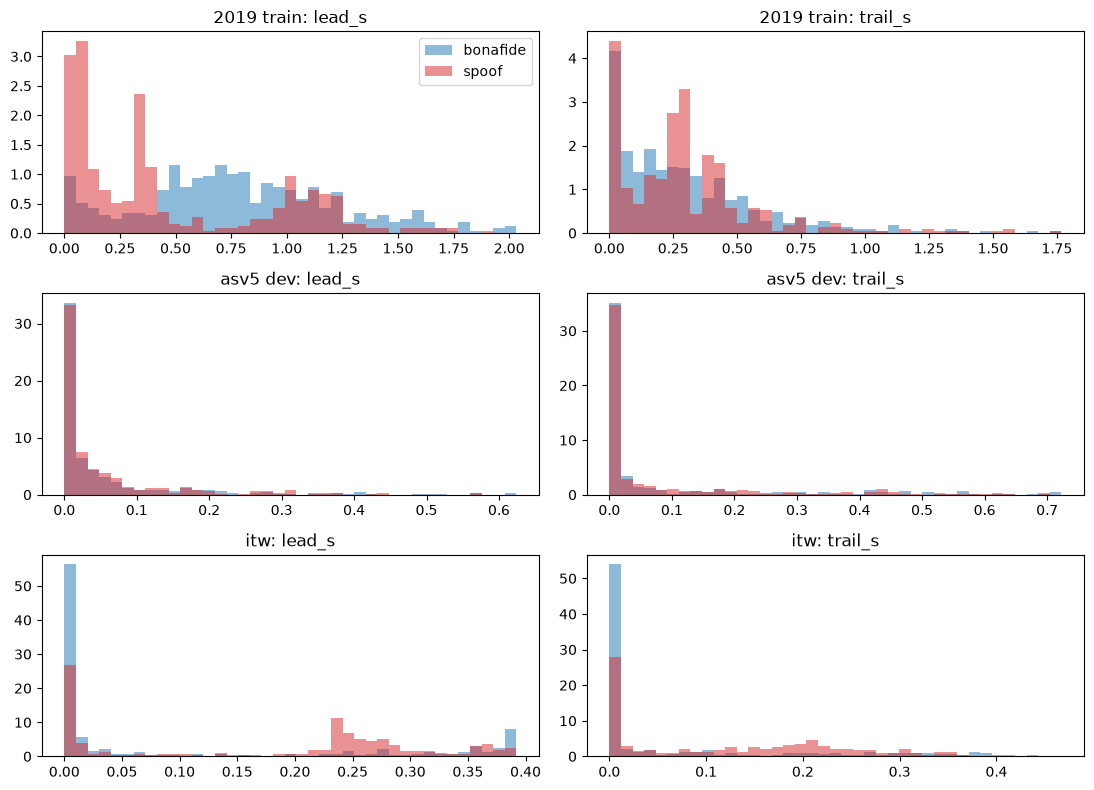

In [32]:
fig, axes = plt.subplots(3, 2, figsize=(11, 8))
for i, (name, t) in enumerate([("2019 train", sil_train), ("asv5 dev", sil_asv5), ("itw", sil_itw)]):
    for j, col in enumerate(["lead_s", "trail_s"]):
        ax = axes[i, j]
        bins = np.linspace(0, t[col].quantile(0.99), 40)
        for label in ["bonafide", "spoof"]:
            ax.hist(t[t.label == label][col], bins=bins, density=True, alpha=0.5, color=colors[label], label=label)
        ax.set_title(f"{name}: {col}")
axes[0, 0].legend()
plt.tight_layout()
plt.show()

In [33]:
for name, t in [("2019 train", sil_train), ("asv5 dev", sil_asv5), ("itw", sil_itw)]:
    print(name)
    print(t.groupby("label")[["lead_s", "trail_s"]].median().round(3))
    print()

2019 train
          lead_s  trail_s
label                    
bonafide   0.752    0.238
spoof      0.336    0.270

asv5 dev
          lead_s  trail_s
label                    
bonafide   0.008      0.0
spoof      0.008      0.0

itw
          lead_s  trail_s
label                    
bonafide   0.008     0.00
spoof      0.232     0.12



In [35]:
def quick_eer(y_true, score):
    fpr, tpr, _ = roc_curve(y_true, score)
    fnr = 1 - tpr
    i = np.nanargmin(np.abs(fnr - fpr))
    return (fpr[i] + fnr[i]) / 2

for name, t in [("2019 train", sil_train), ("asv5 dev", sil_asv5), ("itw", sil_itw)]:
    y = (t.label == "bonafide").astype(int)
    eer = quick_eer(y, t.lead_s)
    print(f"{name}: lead-silence-only EER = {eer * 100:.1f}%")

2019 train: lead-silence-only EER = 31.6%
asv5 dev: lead-silence-only EER = 49.9%
itw: lead-silence-only EER = 66.6%


2019 train: silence alone gets you to ~30% EER. asv5 barely has any edge silence so it doesn't work there. 

itw EER is above 50% (fake clips have more silence there). a model that leaned on this shortcut on 2019 would probably do the wrong thing on itw. 

numbers move around a bit with top_db so these are more rough numbers

## takeaways 

- big class imbalance, different direction per dataset. Weighted loss or balanced sampling, not plain accuracy
- most clips get repeat-padded at train/eval time (2019 + itw), asv5 barely does but we are also only scoring around half of each asv5 clip
- itw spoof clips run longer than bonafide on average (shortcut?)
- asv5 codecs only exist in the eval split, not dev
- leading silence could be shortcut on 2019, doesn't transfer to asv5/itw the same way